# Quickstart to generate  Waveforms with FEW in Time and Frequency Domain

In this tutorial, we demonstrate how to use the Fast EMRI Waveform package to produce waveforms in the time domain (TD) and in the frequency domain (FD).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from few.waveform import GenerateEMRIWaveform
import time as t

time1= t.time()

# Initialize waveform generators
# time domain

td_gen = GenerateEMRIWaveform("FastKerrEccentricEquatorialFlux",sum_kwargs=dict(pad_output=True, odd_len=True),return_list=True)


time2 = t.time()

print(f"Time taken too load: {(time2-time1)/60} minutes")

Time taken too load: 0.35185924371083577 minutes


In [15]:
def stencil(a,da):
    # define the intrinsic parameters
    m1 = 1e6  # central object mass in solar masses
    m2 = 10.0  # secondary object mass in solar masses
    p0 = 1.5  # initial semi-latus rectum
    e0 = 0.2  # eccentricity
    x0 = 1.0  # will be ignored in Schwarzschild waveform
    # initial phases
    Phi_phi0 = np.pi / 3
    Phi_theta0 = 0.0
    Phi_r0 = np.pi / 3
    # define the extrinsic parameters
    qK = np.pi / 3  # polar spin angle
    phiK = np.pi / 3  # azimuthal viewing angle
    qS = np.pi / 3  # polar sky angle
    phiS = np.pi / 3  # azimuthal viewing angle
    dist = 1.0  # distance in Gpc

    Tobs = 0.0023  # observation time, if the inspiral is shorter, the it will be zero padded
    dt = 5.0  # time interval
    eps = 1e-2  # mode content percentage

    a0 = a
    ap2 = a0 + 2*da
    ap1 = a0 + da
    an1 = a0 - da
    an2 = a0 + 2*da

    waveform_kwargs = {"T": Tobs,"dt": dt,"mode_selection_threshold": eps}

    parametersap2 = [m1, m2, ap2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersap1 = [m1, m2, ap1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan2 = [m1, m2, an2, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]
    parametersan1 = [m1, m2, an1, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

    han2 = td_gen(*parametersan2, **waveform_kwargs)[0]
    hap1 = td_gen(*parametersap1, **waveform_kwargs)[0]
    han1 = td_gen(*parametersan1, **waveform_kwargs)[0]
    hap2 = td_gen(*parametersap2, **waveform_kwargs)[0]

    num = -hap2 + 8*hap1 - 8*han1 + han2
    den = 12*da

    derivitave = num/den

    time = np.arange(len(han1)) * dt

    

    return [han2,han1,hap2,hap1] , time,derivitave

In [16]:
hs,t,der1 = stencil(0.998,0.0005)

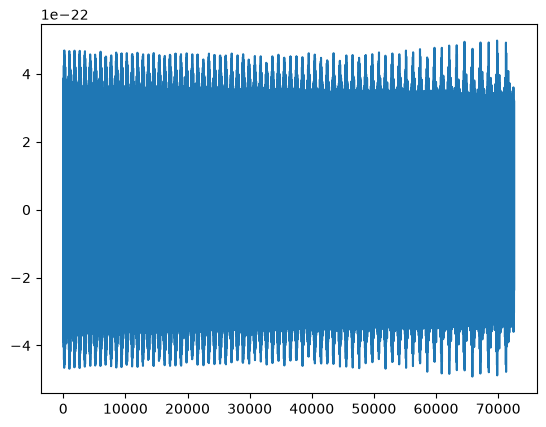

In [17]:
plt.plot(t,hs[1])

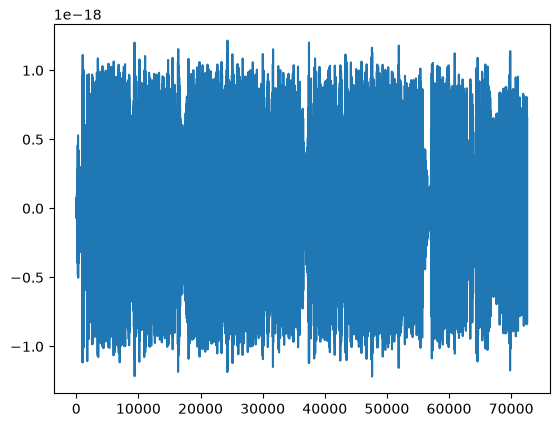

In [18]:
plt.plot(t,der1)

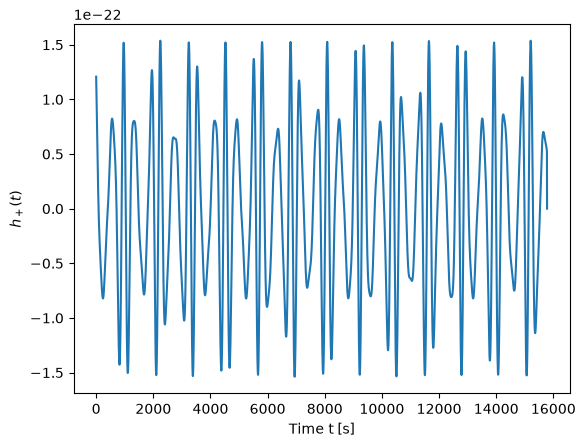

In [3]:
# define the intrinsic parameters
m1 = 1e6  # central object mass in solar masses
a = 0.9999  # dimensionless spin parameter of the central object
m2 = 10.0  # secondary object mass in solar masses
p0 = 8.5  # initial semi-latus rectum
e0 = 0.3  # eccentricity
x0 = 1.0  # will be ignored in Schwarzschild waveform
# initial phases
Phi_phi0 = np.pi / 3
Phi_theta0 = 0.0
Phi_r0 = np.pi / 3
# define the extrinsic parameters
qK = np.pi / 3  # polar spin angle
phiK = np.pi / 3  # azimuthal viewing angle
qS = np.pi / 3  # polar sky angle
phiS = np.pi / 3  # azimuthal viewing angle
dist = 1.0  # distance in Gpc

Tobs = 0.0005  # observation time, if the inspiral is shorter, the it will be zero padded
dt = 5.0  # time interval
eps = 1e-2  # mode content percentage

waveform_kwargs = {"T": Tobs,"dt": dt,"mode_selection_threshold": eps}

parameters = [m1, m2, a, p0, e0, x0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

# create TD signal
waveform_td = td_gen(*parameters, **waveform_kwargs)
time_array = np.arange(len(waveform_td[0])) * dt
# plot the waveform
plt.figure()
plt.plot(time_array, waveform_td[0])
plt.xlabel("Time t [s]")
plt.ylabel("$h_+ (t)$")
plt.show()



In [4]:
time_array

array([0.0000e+00, 5.0000e+00, 1.0000e+01, ..., 1.5770e+04, 1.5775e+04,
       1.5780e+04], shape=(3157,))